In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("data_banknote_authentication.csv")

In [18]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


In [19]:
df.tail()

,Variance,Skewness,Curtosis,Entropy,Class
1368,-1.388700,-4.877300,6.477400,0.341790,1.000000
1369,-3.750300,-13.458600,17.593200,-2.777100,1.000000
1370,-3.563700,-8.382700,12.393000,-1.282300,1.000000
1371,-2.541900,-0.658040,2.684200,1.195200,1.000000
1372,0.433735,1.922353,1.397627,-1.191657,0.444606


In [20]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1373.000000,1373.000000,1373.000000,1373.000000,1373.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.841726,5.866907,4.308459,2.100247,0.496922
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.771300,-1.705100,-1.557200,-2.409900,0.000000
50%,0.495710,2.313400,0.616630,-0.586650,0.000000
75%,2.820900,6.814100,3.176900,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1373 entries, 0 to 1372
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1373 non-null   float64
 1   Skewness  1373 non-null   float64
 2   Curtosis  1373 non-null   float64
 3   Entropy   1373 non-null   float64
 4   Class     1373 non-null   float64
dtypes: float64(5)
memory usage: 53.8 KB


In [22]:
df.shape

(1373, 5)

In [23]:
df.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='str')

class
0    762
1    610
Name: count, dtype: int64


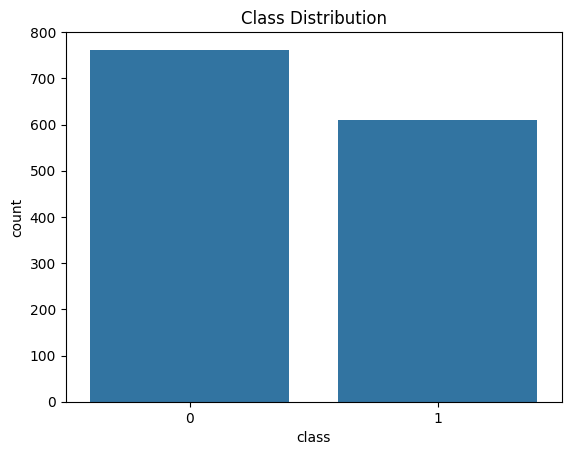

In [27]:
print(df['class'].value_counts())
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

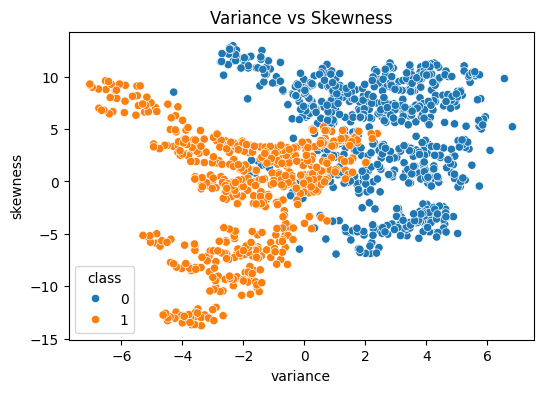

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='variance', y='skewness', hue='class', data=df)
plt.title("Variance vs Skewness")
plt.show()

In [30]:
print(df.isnull().sum())

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [31]:
from sklearn.preprocessing import StandardScaler

X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_rate = []

# Testing K values from 3 to 25
for k in range(3,26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    
    error = np.mean(pred_k != y_test)
    error_rate.append(error)

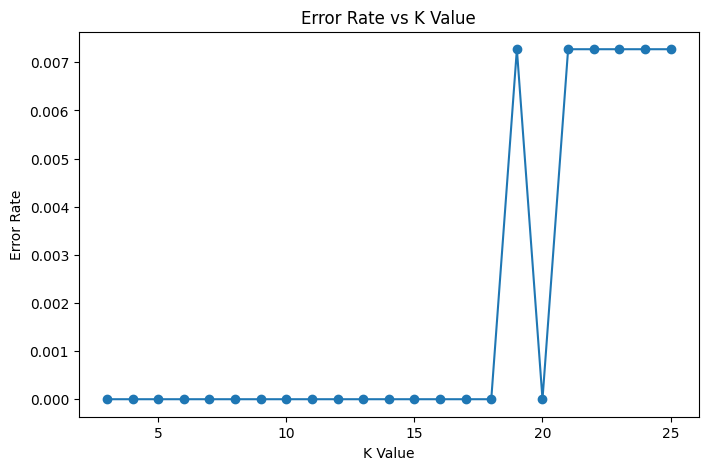

In [34]:
plt.figure(figsize=(8,5))
plt.plot(range(3,26), error_rate, marker='o')
plt.title("Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [35]:
optimal_k = 5

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)

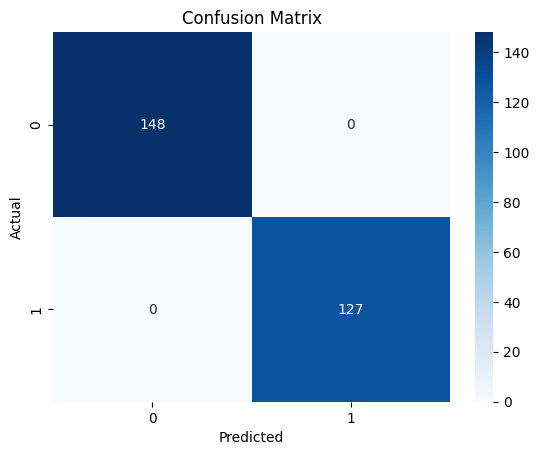

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

